<a href="https://colab.research.google.com/github/lauravfonseca/PeopleAnalytics_citi26/blob/main/Representatividade_feminina_por_%C3%81rea_do_CITi_2026_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas matplotlib openpyxl

In [3]:
!pip install gender-guesser

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 379.3/379.3 kB 11.8 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell I8 is marked as a date but the serial value 14112505400.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)


⚠️ ATENÇÃO: Os 11 desaparecidos devem estar com os seguintes cargos na planilha:
  - 'Diretor de Soluções  (CTO)'
  - 'Quebra de Gestão (Não recebe certificados e declarações de participação)'
-> Se eles precisarem entrar na conta, adicione os textos exatos acima no dicionário 'mapeamento_areas'.

📊 VALIDAÇÃO: Foram agrupadas 60 pessoas com sucesso.

--- TABELA DE REPRESENTATIVIDADE ---


,Total,Mulheres,Porcentagem (%)
Área,,,
Gente e Gestão,4,4,100.0
Marketing,4,4,100.0
Produto,9,7,77.8
Dados,11,4,36.4
Comercial,6,2,33.3
Diretoria,4,1,25.0
Desenvolvimento,22,5,22.7


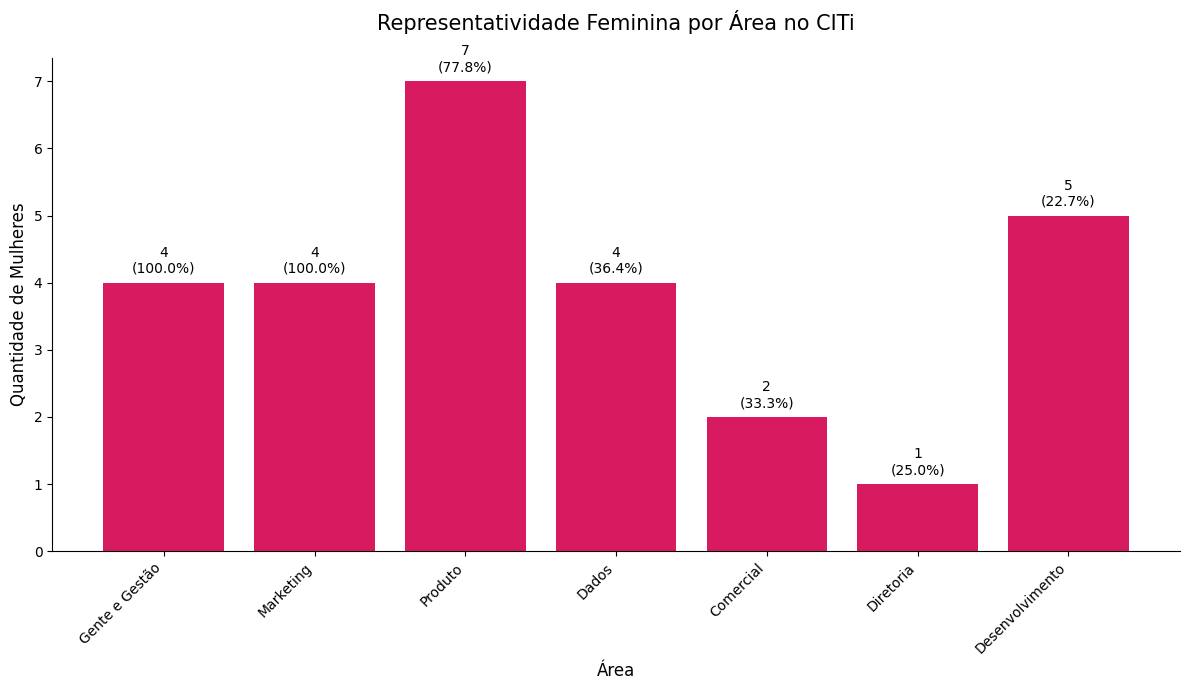

In [8]:
!pip install gender-guesser -q

import pandas as pd
import matplotlib.pyplot as plt
import gender_guesser.detector as gender
import unicodedata

# Função auxiliar para tirar acentos
def remover_acentos(texto):
    texto = str(texto)
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

caminho_do_arquivo = '/content/drive/MyDrive/Cópia de CITiPessoas.xlsx'
df = pd.read_excel(caminho_do_arquivo)

#INFERÊNCIA DE GÊNERO
d = gender.Detector()

def classificar_genero(nome_completo):
    primeiro_nome = str(nome_completo).split()[0]
    primeiro_nome = remover_acentos(primeiro_nome).capitalize()

    excecoes_br = {'Cauan': 'male', 'Lais': 'female'}

    previsao = excecoes_br.get(primeiro_nome)
    if not previsao:
        previsao = d.get_gender(primeiro_nome)

    if previsao in ['female', 'mostly_female']:
        return 'Feminino'
    elif previsao in ['male', 'mostly_male']:
        return 'Masculino'
    else:
        return 'Não Identificado'

col_nome = df.columns[df.columns.str.contains('Nome Completo')][0]
df['Gênero'] = df[col_nome].apply(classificar_genero)
df = df.rename(columns={'Unnamed: 0': 'Cargo'})
df['Cargo'] = df['Cargo'].astype(str).str.strip()

mapeamento_areas = {
    # DESENVOLVIMENTO
    'Pessoa Desenvolvedora': 'Desenvolvimento',
    'Analista de Software': 'Desenvolvimento',
    'Gerente de Software': 'Desenvolvimento',
    'Líder de Desenvolvimento': 'Desenvolvimento',

    # DADOS
    'Analista de Dados': 'Dados',
    'Gerente de Dados': 'Dados',
    'Especialista em Dados': 'Dados',
    'Líder de Dados': 'Dados',

    # PRODUTO
    'UX/UI Designer': 'Produto',
    'UX/Ui Designer': 'Produto',
    'Designer Tech Lead': 'Produto',
    'Líder de Design': 'Produto',

    # COMERCIAL
    'Gerente Comercial': 'Comercial',
    'Gerente de Contas': 'Comercial',
    'Gerente de Produto': 'Comercial',

    # MARKETING
    'Analista de Marketing': 'Marketing',
    'Analista de Makerting': 'Marketing',
    'Especialista de Marketing': 'Marketing',
    'Gerente de Marketing': 'Marketing',

    # GENTE E GESTÃO
    'Consultora Gente e Gestão': 'Gente e Gestão',
    'Especialista de Pessoas': 'Gente e Gestão',
    'Especialista em Cultura': 'Gente e Gestão',
    'Especialista Financeiro': 'Gente e Gestão',

    # DIRETORIA
    'Diretor Institucional (CEO)': 'Diretoria',
    'Diretor de Negócios (CRO)': 'Diretoria',
    'Diretora de Operações (COO)': 'Diretoria',
    'Diretor de Soluções (CTO)': 'Diretoria',
    'Gerente Institucional': 'Diretoria'
}

df['Área'] = df['Cargo'].map(mapeamento_areas)

# --- PARTE C: DIAGNÓSTICO E CÁLCULOS ---
# AVISO DE QUEM FICOU DE FORA
cargos_fora = df[df['Área'].isna()]['Cargo'].unique()

# Filtra remover o "nan" da lista de erros, caso exista alguma linha vazia no Excel
cargos_fora = [c for c in cargos_fora if str(c).lower() != 'nan']

if len(cargos_fora) > 0:
    print("⚠️ ATENÇÃO: Os 11 desaparecidos devem estar com os seguintes cargos na planilha:")
    for c in cargos_fora:
        print(f"  - '{c}'")
    print("-> Se eles precisarem entrar na conta, adicione os textos exatos acima no dicionário 'mapeamento_areas'.\n")

df_valido = df.dropna(subset=['Área'])

# Validação do total de pessoas
total_pessoas_analisadas = len(df_valido)
print(f"📊 VALIDAÇÃO: Foram agrupadas {total_pessoas_analisadas} pessoas com sucesso.\n")

total_area = df_valido.groupby('Área').size()
mulheres_area = df_valido[df_valido['Gênero'] == 'Feminino'].groupby('Área').size()

# Consolida tabela
resumo = pd.DataFrame({'Total': total_area, 'Mulheres': mulheres_area}).fillna(0)
resumo['Porcentagem (%)'] = (resumo['Mulheres'] / resumo['Total']) * 100
resumo = resumo.sort_values(by='Porcentagem (%)', ascending=False)

# Exibe a tabela
print("--- TABELA DE REPRESENTATIVIDADE ---")
display(resumo.round(1))

# --- PARTE D: GRÁFICO ---
plt.figure(figsize=(12, 7))

# Usando o código HEX diretamente
barras = plt.bar(resumo.index, resumo['Mulheres'], color='#D81B60')

for i, barra in enumerate(barras):
    altura = barra.get_height()
    pct = resumo['Porcentagem (%)'].iloc[i]
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.1,
             f'{int(altura)}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.title('Representatividade Feminina por Área no CITi', fontsize=15, pad=20)
plt.xlabel('Área', fontsize=12)
plt.ylabel('Quantidade de Mulheres', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell I8 is marked as a date but the serial value 14112505400.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)


--- TABELA DE REPRESENTATIVIDADE ---


,Total,Mulheres,Porcentagem (%)
Área,,,
Gente e Gestão,4,4,100.0
Marketing,4,4,100.0
Produto,9,7,77.8
Dados,11,4,36.4
Comercial,6,2,33.3
Desenvolvimento,22,5,22.7
Diretoria,5,1,20.0


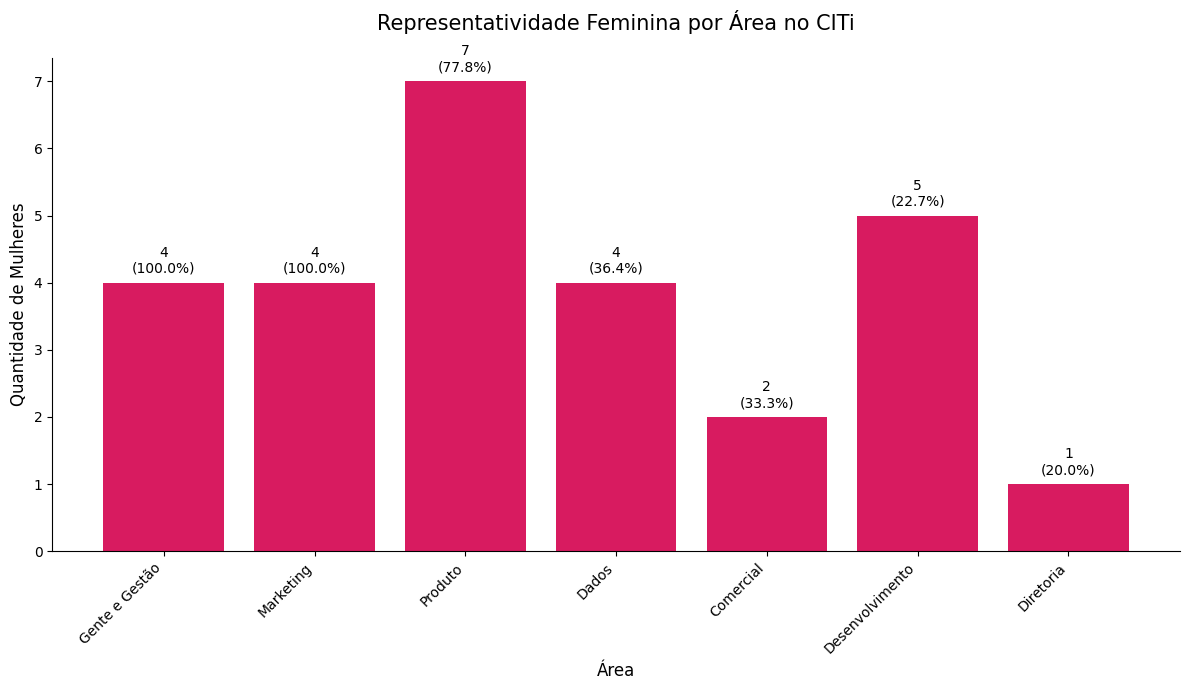

In [9]:
# 1. Instala a biblioteca necessária direto pelo código
!pip install gender-guesser -q

import pandas as pd
import matplotlib.pyplot as plt
import gender_guesser.detector as gender
import unicodedata

# 2. Função auxiliar para tirar acentos
def remover_acentos(texto):
    texto = str(texto)
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

# 3. Carrega a base do seu Google Drive
caminho_do_arquivo = '/content/drive/MyDrive/Cópia de CITiPessoas.xlsx'
df = pd.read_excel(caminho_do_arquivo)

# --- PARTE A: INFERÊNCIA DE GÊNERO ---
d = gender.Detector()

def classificar_genero(nome_completo):
    primeiro_nome = str(nome_completo).split()[0]
    primeiro_nome = remover_acentos(primeiro_nome).capitalize()

    # Exceções brasileiras
    excecoes_br = {'Cauan': 'male', 'Lais': 'female'}

    previsao = excecoes_br.get(primeiro_nome)
    if not previsao:
        previsao = d.get_gender(primeiro_nome)

    if previsao in ['female', 'mostly_female']:
        return 'Feminino'
    elif previsao in ['male', 'mostly_male']:
        return 'Masculino'
    else:
        return 'Não Identificado'

# Identifica a coluna de nome e aplica a classificação
col_nome = df.columns[df.columns.str.contains('Nome Completo')][0]
df['Gênero'] = df[col_nome].apply(classificar_genero)

# --- PARTE B: MAPEAMENTO DE ÁREAS ---
# Renomeia a coluna e remove espaços invisíveis
df = df.rename(columns={'Unnamed: 0': 'Cargo'})
df['Cargo'] = df['Cargo'].astype(str).str.strip()

# DICIONÁRIO DE ÁREAS FINAL
mapeamento_areas = {
    # DESENVOLVIMENTO
    'Pessoa Desenvolvedora': 'Desenvolvimento',
    'Analista de Software': 'Desenvolvimento',
    'Gerente de Software': 'Desenvolvimento',
    'Líder de Desenvolvimento': 'Desenvolvimento',

    # DADOS
    'Analista de Dados': 'Dados',
    'Gerente de Dados': 'Dados',
    'Especialista em Dados': 'Dados',
    'Líder de Dados': 'Dados',

    # PRODUTO
    'UX/UI Designer': 'Produto',
    'UX/Ui Designer': 'Produto',
    'Designer Tech Lead': 'Produto',
    'Líder de Design': 'Produto',

    # COMERCIAL
    'Gerente Comercial': 'Comercial',
    'Gerente de Contas': 'Comercial',
    'Gerente de Produto': 'Comercial',

    # MARKETING
    'Analista de Marketing': 'Marketing',
    'Analista de Makerting': 'Marketing',
    'Especialista de Marketing': 'Marketing',
    'Gerente de Marketing': 'Marketing',

    # GENTE E GESTÃO
    'Consultora Gente e Gestão': 'Gente e Gestão',
    'Especialista de Pessoas': 'Gente e Gestão',
    'Especialista em Cultura': 'Gente e Gestão',
    'Especialista Financeiro': 'Gente e Gestão',

    # DIRETORIA
    'Diretor Institucional (CEO)': 'Diretoria',
    'Diretor de Negócios (CRO)': 'Diretoria',
    'Diretora de Operações (COO)': 'Diretoria',
    'Diretor de Soluções (CTO)': 'Diretoria',
    'Diretor de Soluções  (CTO)': 'Diretoria', # Variação com dois espaços
    'Gerente Institucional': 'Diretoria'
}

df['Área'] = df['Cargo'].map(mapeamento_areas)

# --- PARTE C: CÁLCULOS E TABELA ---
df_valido = df.dropna(subset=['Área'])

total_area = df_valido.groupby('Área').size()
mulheres_area = df_valido[df_valido['Gênero'] == 'Feminino'].groupby('Área').size()

# Consolida tabela
resumo = pd.DataFrame({'Total': total_area, 'Mulheres': mulheres_area}).fillna(0)
resumo['Porcentagem (%)'] = (resumo['Mulheres'] / resumo['Total']) * 100
resumo = resumo.sort_values(by='Porcentagem (%)', ascending=False)

# Exibe a tabela final
print("--- TABELA DE REPRESENTATIVIDADE ---")
display(resumo.round(1))

# --- PARTE D: GRÁFICO ---
plt.figure(figsize=(12, 7))

barras = plt.bar(resumo.index, resumo['Mulheres'], color='#D81B60')

for i, barra in enumerate(barras):
    altura = barra.get_height()
    pct = resumo['Porcentagem (%)'].iloc[i]
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.1,
             f'{int(altura)}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.title('Representatividade Feminina por Área no CITi', fontsize=15, pad=20)
plt.xlabel('Área', fontsize=12)
plt.ylabel('Quantidade de Mulheres', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:223: UserWarning: Cell I8 is marked as a date but the serial value 14112505400.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)


🕵️ DETETIVE: As pessoas contabilizadas como Mulheres em 'Dados' foram:
 - Ana Raquel Rodrigues da Silva
 - Eduarda Rodrigues de Moura Santana
 - Júlia Andrade Gonçalves Bezerra
 - Maria Eduarda Soares Machado
--------------------------------------------------

--- TABELA DE REPRESENTATIVIDADE ---


,Total,Mulheres,Porcentagem (%)
Área,,,
Gente e Gestão,4,4,100.0
Marketing,4,4,100.0
Produto,11,8,72.7
Dados,11,4,36.4
Comercial,4,1,25.0
Desenvolvimento,22,5,22.7
Diretoria,5,1,20.0


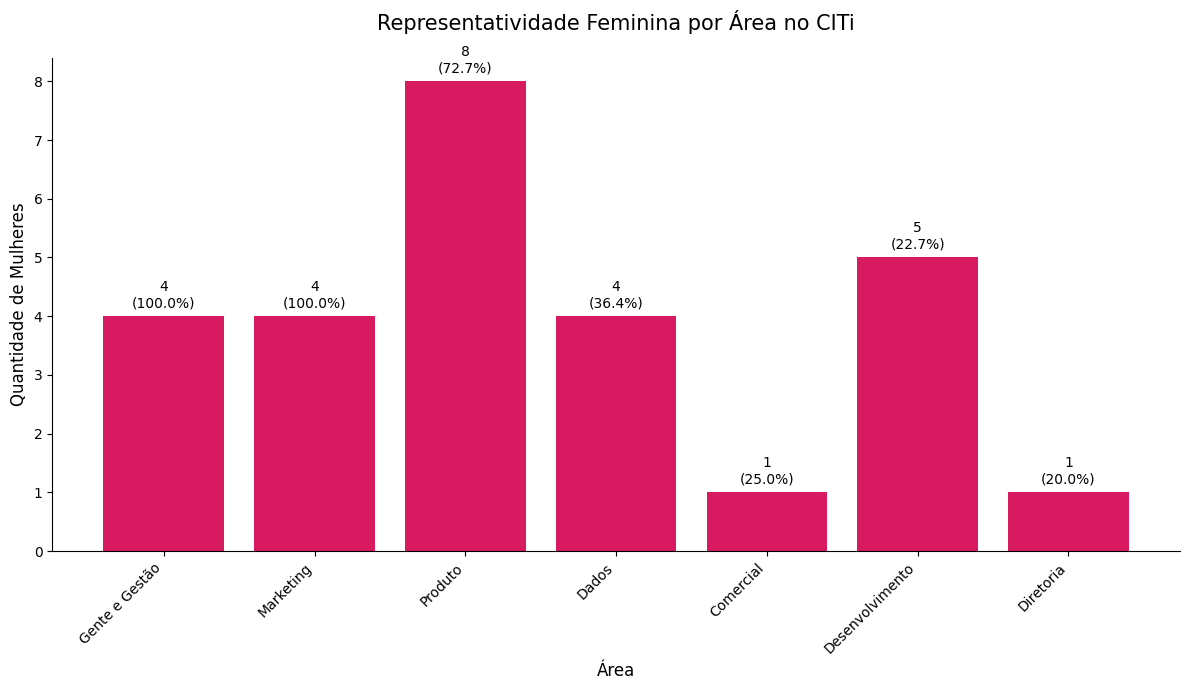

In [11]:
# 1. Instala a biblioteca necessária direto pelo código
!pip install gender-guesser -q

import pandas as pd
import matplotlib.pyplot as plt
import gender_guesser.detector as gender
import unicodedata

# 2. Função auxiliar para tirar acentos
def remover_acentos(texto):
    texto = str(texto)
    return ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')

# 3. Carrega a base do seu Google Drive
caminho_do_arquivo = '/content/drive/MyDrive/Cópia de CITiPessoas.xlsx'
df = pd.read_excel(caminho_do_arquivo)

# --- PARTE A: INFERÊNCIA DE GÊNERO ---
d = gender.Detector()

def classificar_genero(nome_completo):
    primeiro_nome = str(nome_completo).split()[0]
    primeiro_nome = remover_acentos(primeiro_nome).capitalize()

    # ⚠️ COLOQUE O NOME DO MENINO DE DADOS AQUI EMBAIXO COM ': 'male' ⚠️
    excecoes_br = {
        'Cauan': 'male', 'Lais': 'female', 'Rafael': 'male',
        'Gabriel': 'male', 'Yuri': 'male', 'Davi': 'male',
        'Guilherme': 'male', 'Arthur': 'male', 'Lucas': 'male'
    }

    previsao = excecoes_br.get(primeiro_nome)
    if not previsao:
        previsao = d.get_gender(primeiro_nome)

    if previsao in ['female', 'mostly_female']:
        return 'Feminino'
    elif previsao in ['male', 'mostly_male']:
        return 'Masculino'
    else:
        return 'Não Identificado'

# Identifica a coluna de nome e aplica a classificação
col_nome = df.columns[df.columns.str.contains('Nome Completo')][0]
df['Gênero'] = df[col_nome].apply(classificar_genero)

# --- PARTE B: MAPEAMENTO DE ÁREAS ---
# Renomeia a coluna e remove espaços invisíveis
df = df.rename(columns={'Unnamed: 0': 'Cargo'})
df['Cargo'] = df['Cargo'].astype(str).str.strip()

# DICIONÁRIO DE ÁREAS FINAL (Gerente de Produto movido)
mapeamento_areas = {
    'Pessoa Desenvolvedora': 'Desenvolvimento', 'Analista de Software': 'Desenvolvimento', 'Gerente de Software': 'Desenvolvimento', 'Líder de Desenvolvimento': 'Desenvolvimento',
    'Analista de Dados': 'Dados', 'Gerente de Dados': 'Dados', 'Especialista em Dados': 'Dados', 'Líder de Dados': 'Dados',
    'UX/UI Designer': 'Produto', 'UX/Ui Designer': 'Produto', 'Designer Tech Lead': 'Produto', 'Líder de Design': 'Produto', 'Gerente de Produto': 'Produto',
    'Gerente Comercial': 'Comercial', 'Gerente de Contas': 'Comercial',
    'Analista de Marketing': 'Marketing', 'Analista de Makerting': 'Marketing', 'Especialista de Marketing': 'Marketing', 'Gerente de Marketing': 'Marketing',
    'Consultora Gente e Gestão': 'Gente e Gestão', 'Especialista de Pessoas': 'Gente e Gestão', 'Especialista em Cultura': 'Gente e Gestão', 'Especialista Financeiro': 'Gente e Gestão',
    'Diretor Institucional (CEO)': 'Diretoria', 'Diretor de Negócios (CRO)': 'Diretoria', 'Diretora de Operações (COO)': 'Diretoria', 'Diretor de Soluções (CTO)': 'Diretoria', 'Diretor de Soluções  (CTO)': 'Diretoria', 'Gerente Institucional': 'Diretoria'
}

df['Área'] = df['Cargo'].map(mapeamento_areas)

# --- PARTE C: CÁLCULOS E TABELA ---
df_valido = df.dropna(subset=['Área'])

# DETETIVE DE DADOS: Mostra quem são as "mulheres" em Dados
mulheres_dados = df_valido[(df_valido['Área'] == 'Dados') & (df_valido['Gênero'] == 'Feminino')]
print("🕵️ DETETIVE: As pessoas contabilizadas como Mulheres em 'Dados' foram:")
for nome in mulheres_dados[col_nome]:
    print(f" - {nome}")
print("-" * 50 + "\n")

total_area = df_valido.groupby('Área').size()
mulheres_area = df_valido[df_valido['Gênero'] == 'Feminino'].groupby('Área').size()

# Consolida tabela
resumo = pd.DataFrame({'Total': total_area, 'Mulheres': mulheres_area}).fillna(0)
resumo['Porcentagem (%)'] = (resumo['Mulheres'] / resumo['Total']) * 100
resumo = resumo.sort_values(by='Porcentagem (%)', ascending=False)

# Exibe a tabela final
print("--- TABELA DE REPRESENTATIVIDADE ---")
display(resumo.round(1))

# --- PARTE D: GRÁFICO ---
plt.figure(figsize=(12, 7))

barras = plt.bar(resumo.index, resumo['Mulheres'], color='#D81B60')

for i, barra in enumerate(barras):
    altura = barra.get_height()
    pct = resumo['Porcentagem (%)'].iloc[i]
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.1,
             f'{int(altura)}\n({pct:.1f}%)',
             ha='center', va='bottom', fontsize=10)

plt.title('Representatividade Feminina por Área no CITi', fontsize=15, pad=20)
plt.xlabel('Área', fontsize=12)
plt.ylabel('Quantidade de Mulheres', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()